# 05: Poređenje sirovog TF-IDF i SVD(100) prolaza

Sekcija čita csv-ove dva prolaza (csv/ = SVD(100)+L2, raw/csv/ = sirovi TF-IDF) i spaja ih u tabele poređenja; štampa šta fali.

Napomene:
- NMF je u oba prolaza na sirovom TF-IDF-u, pa se ne poredi
- BIRCH se ne računa u sirovom prolazu (memorija potklastera)
- silueta/DB/CH nisu uporedivi između prostora različitih dimenzionalnosti; porede se čistoća, pokrivenost, izabrani k i oblik krive skana


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if not (os.path.isdir("csv") and os.path.isdir("raw")):
    raise FileNotFoundError("Nije pronadjen put")

PASSES = [("SVD(100)", "."), ("raw TF-IDF", "raw")]

TABLES = {
    "algorithm_table":   ["{name}.csv"],
    "bestk_table":       ["csv/{name}.csv"],
    "nonk_param_best":   ["csv/{name}.csv"],
    "param_scan_documents": ["csv/{name}.csv"],
    "kscan_2_120":       ["csv/{name}.csv"],
    "sent_algorithm_table": ["csv/{name}.csv"],
    "sent_bestk_table":  ["csv/{name}.csv"],
}

def load(table_name):
    out, missing = {}, []
    for pass_name, prefix in PASSES:
        for pattern in TABLES[table_name]:
            path = os.path.join(prefix, pattern.format(name=table_name))
            if os.path.exists(path):
                out[pass_name] = pd.read_csv(path)
                break
        else:
            missing.append(pass_name)
    if missing:
        print(f"[{table_name}] nedostaje za: " + ", ".join(missing))
    return out

def combine(table_name):
    frames = load(table_name)
    if not frames:
        return None
    return pd.concat(
        [df.assign(space=pass_name) for pass_name, df in frames.items()],
        ignore_index=True)

def save(df, table_name):
    if df is not None:
        df.to_csv(f"csv/comparison_{table_name}.csv", index=False)
        print(f"-> csv/comparison_{table_name}.csv")

print("spremno")

spremno


## 1. Tabela algoritama na k=20 (dokumenti)

Čistoća i pokrivenost po algoritmu i prostoru; silueta samo kao informacija unutar svakog prostora.

-> csv/comparison_algorithm_table_k20.csv


coverage              purity            silhouette  \
space                SVD(100) raw TF-IDF SVD(100) raw TF-IDF   SVD(100)   
algorithm                                                                 
Agglomerative (ward)    1.000      1.000    0.474      0.454      0.019   
BIRCH                   1.000        NaN    0.486        NaN      0.024   
Bisecting K-Means       1.000      1.000    0.488      0.465      0.046   
DBSCAN                  0.665      0.075    0.246      0.030      0.023   
GMM                     1.000      1.000    0.506      0.486      0.023   
K-Means                 1.000      1.000    0.522      0.507      0.077   
Spectral (k-NN)         1.000      1.000    0.461      0.480      0.054   

                                 
space                raw TF-IDF  
algorithm                        
Agglomerative (ward)     -0.008  
BIRCH                       NaN  
Bisecting K-Means        -0.000  
DBSCAN                    0.176  
GMM                       0.002  
K-Means                   0.009  
Spectral (k-NN)           0.007

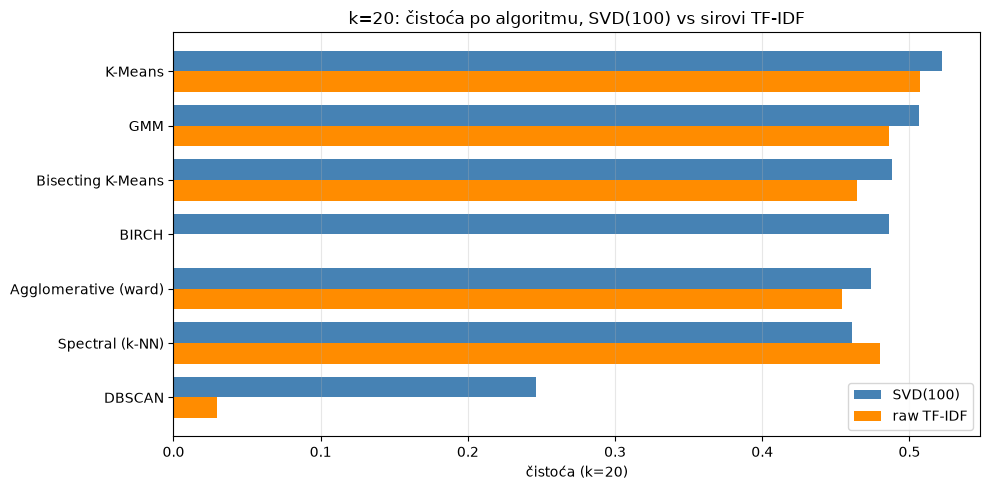

In [2]:
df = combine("algorithm_table")
if df is not None:
    df = df[~df.algorithm.str.contains("NMF")]  # ista reprezentacija u oba
    save(df, "algorithm_table_k20")
    pivot = df.pivot_table(index="algorithm", columns="space",
                           values=["purity", "coverage", "silhouette"])
    display(pivot.round(3))
    df["purity_delta"] = (df.groupby("algorithm").purity
                          .transform(lambda s: s.diff().iloc[-1]
                                     if len(s) > 1 else np.nan))
    fig, ax = plt.subplots(figsize=(10, 5))
    ordered = df[df.space == "SVD(100)"].sort_values("purity")
    y = np.arange(len(ordered))
    h = 0.38
    for pass_name, color in (("SVD(100)", "steelblue"),
                             ("raw TF-IDF", "darkorange")):
        current = df[df.space == pass_name].set_index("algorithm")
        values = ordered.algorithm.map(current.purity).to_numpy()
        ax.barh(y + (h/2 if pass_name == "SVD(100)" else -h/2), values,
                height=h, color=color, label=pass_name)
    ax.set_yticks(y); ax.set_yticklabels(ordered.algorithm)
    ax.set_xlabel("čistoća (k=20)")
    ax.set_title("k=20: čistoća po algoritmu, SVD(100) vs sirovi TF-IDF")
    ax.legend(); ax.grid(alpha=.3, axis="x")
    plt.tight_layout(); plt.show()

## 2. Najbolji k po algoritmu

Izbor k po silueti iz skanova sekcije 2; zanimljiv deo priče — sirovi prostor pomera izbor ka malim k.

In [3]:
df = combine("bestk_table")
if df is not None:
    save(df, "bestk_table")
    display(df.round(4))
    if df.space.nunique() > 1:
        pivot = df.pivot_table(index="algorithm", columns="space",
                               values="k_best")
        display(pivot)
else:
    print("(nedostaju tabele sirovog prolaza)")

-> csv/comparison_bestk_table.csv


,algorithm,k_best,silhouette,purity,space
0,K-Means,72,0.0950,0.5660,SVD(100)
1,Bisecting K-Means,5,0.0790,0.4295,SVD(100)
2,Agglomerative (ward),5,0.0442,0.4256,SVD(100)
3,GMM (diag),50,0.0625,0.5423,SVD(100)
4,Spectral (k-NN),12,0.0611,0.4331,SVD(100)
5,BIRCH,5,0.0352,0.4172,SVD(100)
6,NMF,2,0.0998,0.3874,SVD(100)
7,K-Means,5,-0.0003,0.4344,raw TF-IDF
8,Bisecting K-Means,4,0.0096,0.4329,raw TF-IDF
9,Agglomerative (ward),2,0.0132,0.3874,raw TF-IDF


space,SVD(100),raw TF-IDF
algorithm,,
Agglomerative (ward),5.0,2.0
BIRCH,5.0,NaN
Bisecting K-Means,5.0,4.0
GMM (diag),50.0,4.0
K-Means,72.0,5.0
NMF,2.0,20.0
Spectral (k-NN),12.0,30.0


## 3. Ne-k parametri

Izbor parametara po algoritmu (BIC, eps, prag...) i revizija iz sekcije 6 — poklapaju li se izbori između prostora.

In [4]:
df = combine("nonk_param_best")
if df is not None:
    save(df, "nonk_param_best")
    display(df.pivot_table(index=["algorithm", "parameter"],
                           columns="space", values="chosen",
                           aggfunc=lambda s: " / ".join(map(str, s))))
df2 = combine("param_scan_documents")
if df2 is not None:
    save(df2, "param_scan_documents")
    display(df2[df2.param.isin(["covariance(BIC)",
                                "min_samples(eps rule)",
                                "n_neighbors"])]
              [["space", "algorithm", "param", "value",
                "purity", "sil", "note"]]
              .sort_values(["param", "space"]).round(4))

-> csv/comparison_nonk_param_best.csv


,space,SVD(100),raw TF-IDF
algorithm,parameter,,
BIRCH,threshold,0.3,NaN
DBSCAN,eps,0.85,1.1
GMM,covariance_type,diag,diag


-> csv/comparison_param_scan_documents.csv


,space,algorithm,param,value,purity,sil,note
8,SVD(100),GMM,covariance(BIC),spherical BIC=-2652788,0.5082,0.0405,NaN
9,SVD(100),GMM,covariance(BIC),diag BIC=-2685062,0.5064,0.0233,selected by BIC
10,SVD(100),GMM,covariance(BIC),tied BIC=-2651585,0.5051,0.0471,NaN
11,SVD(100),GMM,covariance(BIC),full BIC=-2250741,0.5137,0.0502,NaN
42,raw TF-IDF,GMM,covariance(BIC),spherical BIC=-622803253,0.4981,0.0074,NaN
43,raw TF-IDF,GMM,covariance(BIC),diag BIC=-864159160,0.4862,0.0017,selected by BIC
17,SVD(100),DBSCAN,min_samples(eps rule),"ms=5, eps=0.8",0.2008,-0.1057,NaN
18,SVD(100),DBSCAN,min_samples(eps rule),"ms=10, eps=0.85",0.2464,0.0227,current choice
19,SVD(100),DBSCAN,min_samples(eps rule),"ms=20, eps=0.85",0.2193,0.0122,NaN
20,SVD(100),DBSCAN,min_samples(eps rule),"ms=30, eps=0.85",0.1974,0.1192,NaN


## 4. Krive skana k=2..120 (K-Means)

Vrednosti siluete nisu uporedive između prostora — gleda se **oblik** krive i gde je argmax.

-> csv/comparison_kscan_2_120.csv
SVD(100): argmax siluete na k=72 (0.0950)
raw TF-IDF: argmax siluete na k=97 (0.0179)


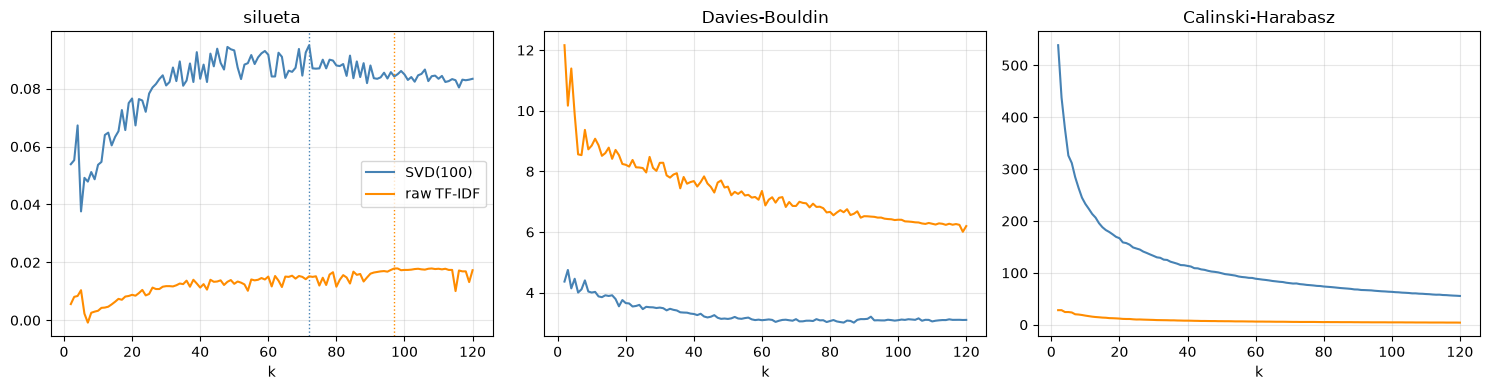

In [5]:
df = combine("kscan_2_120")
if df is not None:
    save(df, "kscan_2_120")
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for pass_name, color in (("SVD(100)", "steelblue"), ("raw TF-IDF", "darkorange")):
        d = df[df.space == pass_name]
        axes[0].plot(d.k, d.silhouette, color=color, label=pass_name)
        axes[1].plot(d.k, d.db, color=color)
        axes[2].plot(d.k, d.ch, color=color)
        kbest = int(d.loc[d.silhouette.idxmax(), "k"])
        axes[0].axvline(kbest, color=color, ls=":", lw=1)
        print(f"{pass_name}: argmax siluete na k={kbest} "
              f"({d.silhouette.max():.4f})")
    for ax, (column, title) in zip(axes, [("silhouette", "silueta"),
                                          ("db", "Davies-Bouldin"),
                                          ("ch", "Calinski-Harabasz")]):
        ax.set_xlabel("k"); ax.set_title(title); ax.grid(alpha=.3)
    axes[0].legend()
    plt.tight_layout(); plt.show()

## 5. Rečenice (223k)

Čistoća na 1 468 anotiranih i nasleđena čistoća; BIRCH fali sa sirove strane, NMF je zajednička reprezentacija.

In [6]:
df = combine("sent_algorithm_table")
if df is not None:
    df = df[~df.algorithm.str.contains("NMF")]
    save(df, "sent_algorithm_table")
    columns = [c for c in ("algorithm", "space", "coverage",
                           "purity_inherited", "capture_1468_true",
                           "silhouette", "n_clusters") if c in df]
    display(df[columns].round(3))
df2 = combine("sent_bestk_table")
if df2 is not None:
    save(df2, "sent_bestk_table")
    display(df2.round(4))

-> csv/comparison_sent_algorithm_table.csv


,algorithm,space,coverage,purity_inherited,capture_1468_true,silhouette,n_clusters
0,K-Means,SVD(100),1.0,0.388,0.279,0.140,20
1,Bisecting K-Means,SVD(100),1.0,0.390,0.273,0.050,20
2,GMM,SVD(100),1.0,0.387,0.262,-0.028,20
4,BIRCH,SVD(100),1.0,0.392,0.240,0.037,20
5,K-Means,raw TF-IDF,1.0,0.390,0.250,0.015,20
7,GMM,raw TF-IDF,1.0,0.387,0.230,-0.000,20
8,Bisecting K-Means,raw TF-IDF,1.0,0.385,0.221,0.009,20


-> csv/comparison_sent_bestk_table.csv


,algorithm,k_best,silhouette,purity_inherited,purity_true1468,space
0,K-Means,60,0.2373,0.4037,0.3420,SVD(100)
1,Bisecting K-Means,60,0.1121,0.3988,0.3283,SVD(100)
2,GMM (diag),50,-0.0498,0.3905,0.2868,SVD(100)
3,BIRCH,60,0.1240,0.4007,0.3304,SVD(100)
4,NMF,60,0.1575,0.3977,0.3488,SVD(100)
5,K-Means,60,0.0349,0.3992,0.2943,raw TF-IDF
6,Bisecting K-Means,40,0.0093,0.3877,0.2609,raw TF-IDF
7,GMM (diag),60,0.0037,0.3873,0.2418,raw TF-IDF
8,NMF,60,0.0193,0.3977,0.3488,raw TF-IDF


## 6. Spectral na malim k (2..4)

Provera da li mali k drže strukturu i kod Spektralne metode, u oba prostora. Poslednja kolona je slaganje particija dva prostora na istom k (ARI).

In [7]:
if os.path.exists("csv/spectral_small_k.csv"):
    display(pd.read_csv("csv/spectral_small_k.csv"))
else:
    print("nedostaje csv/spectral_small_k.csv")

,prolaz,k,purity,silhouette,n_clusters,ari_raw_vs_svd
0,SVD(100),2,0.3883,0.0680,2,-0.0044
1,raw TF-IDF,2,0.3880,0.0107,2,-0.0044
2,SVD(100),3,0.3889,0.0618,3,0.0093
3,raw TF-IDF,3,0.4299,0.0046,3,0.0093
4,SVD(100),4,0.3889,0.0652,4,0.1291
5,raw TF-IDF,4,0.4366,0.0079,4,0.1291
